In [25]:
# Importamos las librerías comunes
import pandas as pd
import numpy as np
import scipy.stats as scipystats
from scipy.stats import kurtosis, norm, skew
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

### 3. Exploratory Data Analysis
El objetivo través de la exploración de datos es comprender la estructura, calidad y comportamiento estadístico de los datos **Home Equity Loan (hmeq)**. Es un paso crítico antes de tomar cualquier decisión en el preprocesamiento o modelización.   
El EDA esta centrado con el objetivo principal del TFM (punto 1.2), estimar la **Probabilidad de Incumplimiento (PD – Probability of Default)** de una cartera de préstamos con garantía hipotecaria con el fin de <u> predecir la probabilidad de que un prestatario incurra en impago. </u>    

El análisis se estructura de forma progresiva:  
<small>

|  Análisis  | Descripción
|----------|:---------|
| **Visión general del dataset**  | Revisar la dimensión, estructura, clasificación funcional tipología de variables
| **Análisis de la variable objetivo** |  Definición de la variable objetivo BAD
| **Análisis univariante** |  Examinar medidas de centralización, dispersión, forma de las distribuciones, asimetría y curtosis.
| **Calidad del dato** | Missing values y outliers por variable
| **Análisis multivariante** |  evaluar la relación entre las variables explicativas y la variable objetivo asi como detectar problemas de colinealidad.

</small>

El EDA servirá como base para el desarrollo de modelos de clasificación probabilística, empleando como modelo de referencia una regresión logística. Sobre esta base, se explorará posteriormente el uso de modelos (Decision Tree, Random Forest, Gradient Boosting) siempre con el objetivo principal de comparar el rendimiento predictivo y la capacidad de estimación de probabilidades.

#### 3.1 Visión general del dataset

In [49]:
# Cargar el dataset y mostrar algunas filas.
hmeq = pd.read_csv('../data/raw/hmeq.csv')
hmeq.head(4)

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



El dataset HMEQ (Home Equity Loans) recoge información histórica sobre una cartera de préstamos concedidos con garantía sobre el valor de la vivienda del prestatario. Este tipo de productos es habitual en carteras retail hipotecarias, donde el colateral inmobiliario juega un papel relevante en el perfil de riesgo.  
Cada fila del conjunto de datos corresponde a una solicitud u operación de préstamo, para la cual se dispone de información financiera, laboral y de comportamiento crediticio, así como del estado de impago reflejado en la variable objetivo.

In [50]:
print("Informacion del dataset:")
hmeq.info()

Informacion del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


- Tenemos <u> 5960 registros con 13 columnas </u>, donde hay missing values en 10 columnas: Todas excepto la variable target (BAD) y el importe del prestamo (LOAN).   
- Respecto a la tipología de variable, tan solo la finalidad del préstamo **(REASON) y JOB son categóricas** mientras que el **resto son numéricas**.
- Atendiendo a la descripción funcional de la variables explicativas parece que todas van a jugar un papel considerable en la clasificación de la variable objetivo BAD.  

<span style="font-size:14px">

|  Variable |  Grupo funcional | Descripción
|----------|:---------|:---------|
| BAD  | Objetivo | Indica si el cliente ha incumplido (1) o no (0) en el pago del préstamo
| LOAN | Financieras | Importe del préstamo solicitado
| MORTDUE | Financieras | Saldo pendiente de la hipoteca existente
| DEBTINC | Financieras | Ratio deuda-ingresos del prestatario
| VALUE | Financieras | Valor estimado de la propiedad
| DEROG |Comportamiento crediticio | Número de incidencias crediticias graves
| DELINQ |Comportamiento crediticio | Número de líneas de crédito en mora
| NINQ |Comportamiento crediticio | Número de consultas recientes de crédito
| CLAGE |Comportamiento crediticio | Antigüedad de la línea de crédito más antigua (meses)
| CLNO |Comportamiento crediticio | Número total de líneas de crédito
| REASON |Comportamiento crediticio | Finalidad del préstamo
| YOJ |Laborales | Años en el empleo actual
| JOB |Laborales | Categoría ocupacional del prestatario

<span>




#### 3.2 Análisis de la variable objetivo

In [51]:
# Análisis de la variable objetivo 'BAD'
target = hmeq['BAD']
target_sano = target[target == 0].count() / target.count() * 100
target_malo = target[target == 1].count() / target.count() * 100
print(f'La muestra contiene un {target_sano:.2f}% de clientes al corriente de pago mientras que un {target_malo:.2f}% son default')

La muestra contiene un 80.05% de clientes al corriente de pago mientras que un 19.95% son default


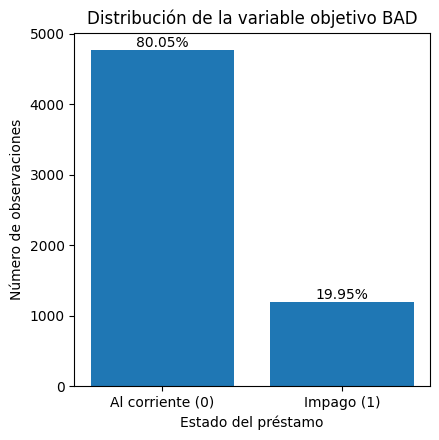

In [52]:
# Visualización
counts = target.value_counts().sort_index()
porcentages = counts / counts.sum() * 100
plt.figure(figsize=(4.5, 4.5))
bars = plt.bar(
    ["Al corriente (0)", "Impago (1)"],
    counts.values
)
for bar, pct in zip(bars, porcentages.values): # Etiquetar los % 
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{pct:.2f}%",
        ha="center",
        va="bottom"
    )
plt.title("Distribución de la variable objetivo BAD")
plt.xlabel("Estado del préstamo")
plt.ylabel("Número de observaciones")
plt.tight_layout()
plt.show()

La variable BAD presenta una distribución claramente desbalanceada, con aproximadamente un 80 % de préstamos al corriente de pago (BAD = 0) frente a un 20 % en situación de impago (BAD = 1). Este comportamiento es consistente con carteras reales de crédito retail, donde los eventos de default son relativamente infrecuentes.
Este **desbalanceo** tiene implicaciones metodológicas relevantes. Ante estos problemas, la métrica **accuracy** deja de ser efectivo para medir desempeño global del modelo pues cuantifica el porcentaje de predicciones correctas y en problemas desbalanceados no es correcto. Si el modelo identificase todos los registros al corriente de pago y no detectase falsos negativos (clientes realmente en default), tendría una accuracy del 80% y esto provocaría un riesgo real de crédito para la entidad financiera.  
Por lo tanto, la evaluación se basará en métricas más apropiadas para problemas de clasificación desbalanceada y estimación de probabilidades, tales como **el área bajo la curva ROC (AUC), el coeficiente de Gini, el Brier Score y el análisis de calibración**. Estas métricas permiten evaluar tanto la capacidad discriminante del modelo como la calidad de las probabilidades estimadas, aspectos clave en la modelización de la Probabilidad de Incumplimiento (PD).


In [ ]:
num_vars_target = hmeq.select_dtypes('number')
spearman_corr = num_vars_target.corr(method='spearman')
corr_with_target = spearman_corr['BAD'].sort_values(ascending=False)
# Dataframe
corr_with_target = corr_with_target.reset_index().rename(columns={'index': 'Variable', 'BAD': 'Correlación con BAD'})


AttributeError: 'DataFrame' object has no attribute 'to_DataFrame'

#### 3.3 Análisis univariante

In [54]:
print("Resumen estadístico del dataset:")
hmeq.describe().round(2)

Resumen estadístico del dataset:


,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.0,5960.00,5442.00,5848.00,5445.00,5252.00,5380.00,5652.00,5450.00,5738.00,4693.00
mean,0.2,18607.97,73760.82,101776.05,8.92,0.25,0.45,179.77,1.19,21.30,33.78
std,0.4,11207.48,44457.61,57385.78,7.57,0.85,1.13,85.81,1.73,10.14,8.60
min,0.0,1100.00,2063.00,8000.00,0.00,0.00,0.00,0.00,0.00,0.00,0.52
25%,0.0,11100.00,46276.00,66075.50,3.00,0.00,0.00,115.12,0.00,15.00,29.14
50%,0.0,16300.00,65019.00,89235.50,7.00,0.00,0.00,173.47,1.00,20.00,34.82
75%,0.0,23300.00,91488.00,119824.25,13.00,0.00,0.00,231.56,2.00,26.00,39.00
max,1.0,89900.00,399550.00,855909.00,41.00,10.00,15.00,1168.23,17.00,71.00,203.31


##### Medidas (Centralización, localización, dispersión)

<small>

<h3 style="margin-bottom:0px;">Medidas de centralización</h3>
<p style="margin-top:1px;">
Si atendemos a la diferencia entre la media y la mediana:  
    - Vemos asimetría positiva en variables de comportamiento crediticio, como el número de lineas de crédito en mora (**DELINQ**) como en el número de incidencias crediticias (**DEROG**). Esto sugiere que hay una elevada concentración de observaciones en cero y pocos prestatarios con valores elevados. De forma similar, la variable **NINQ** (número de consultas recientes de crédito) muestra una distribución sesgada a la derecha, reflejando que la mayoría de los solicitantes realiza pocas consultas, mientras que un número reducido concentra valores altos.  
    - Del mismo modo ocurre con el número total de lineas de crédito (**CLNO**) la antiguedad de las lineas de crédito (**CLAGE**), el ratio de deuda ingresos (**DEBTINC**), el saldo pendiente de la hipoteca (**MORTDUE**) y el valor de la propiedad (**VALUE**) donde la media es superior a la mediana y por lo tanto pocos clientes con un alto número de lineas de crédito o antiguedad muy alta, un ratio muy alto, un salgo pendiente elevado o un valor de la propiedad alto. Esto indica la presencia de colas derechas largas. 
    - Encontramos una asimetría moderada en **LOAN** y antiguedad laboral (**YOJ**)
    - Concluyendo las variables más asimétricas son las de comportamiento crediticio (DELING, DEROG, NINQ)
    - Más adelante analizaremos la distribución visualmente.  

</p>

<h3 style="margin-bottom:0px;">Medidas de localización</h3>
<p style="margin-top:3px;">
En la mayoría de las variables, los valores se concentran en los cuartiles inferiores, mientras que los valores extremos se encuentran muy alejados del tercer cuartil, evidenciando colas derechas largas.

</p>

<h3 style="margin-bottom:0px;">Medidas de dispersión</h3>
<p style="margin-top:3px;">
Atendiendo a la media y la desvición típica, observamos que variables de comportamiento crediticio (**DELINQ, DEROG, NINQ**) presentan una desviación elevada en comparación con su media. Si atendemos a los cuartiles, podemos concluir que un número reducido de clientes presentan altos riesgos tanto en incidencias como lineas en mora.
En relación a variables financieras como (**LOAN, MORTDUE, VALUE**) observamos que la desviación típica es muy alta. De estos datos, podemos deducir que la distribuación es más alargada y que existe heterogeneidad de importes, saldos y valoración de activos 
</p>


</small>


##### Análisis de distribuciones por histogramas, asimetría y curtosis

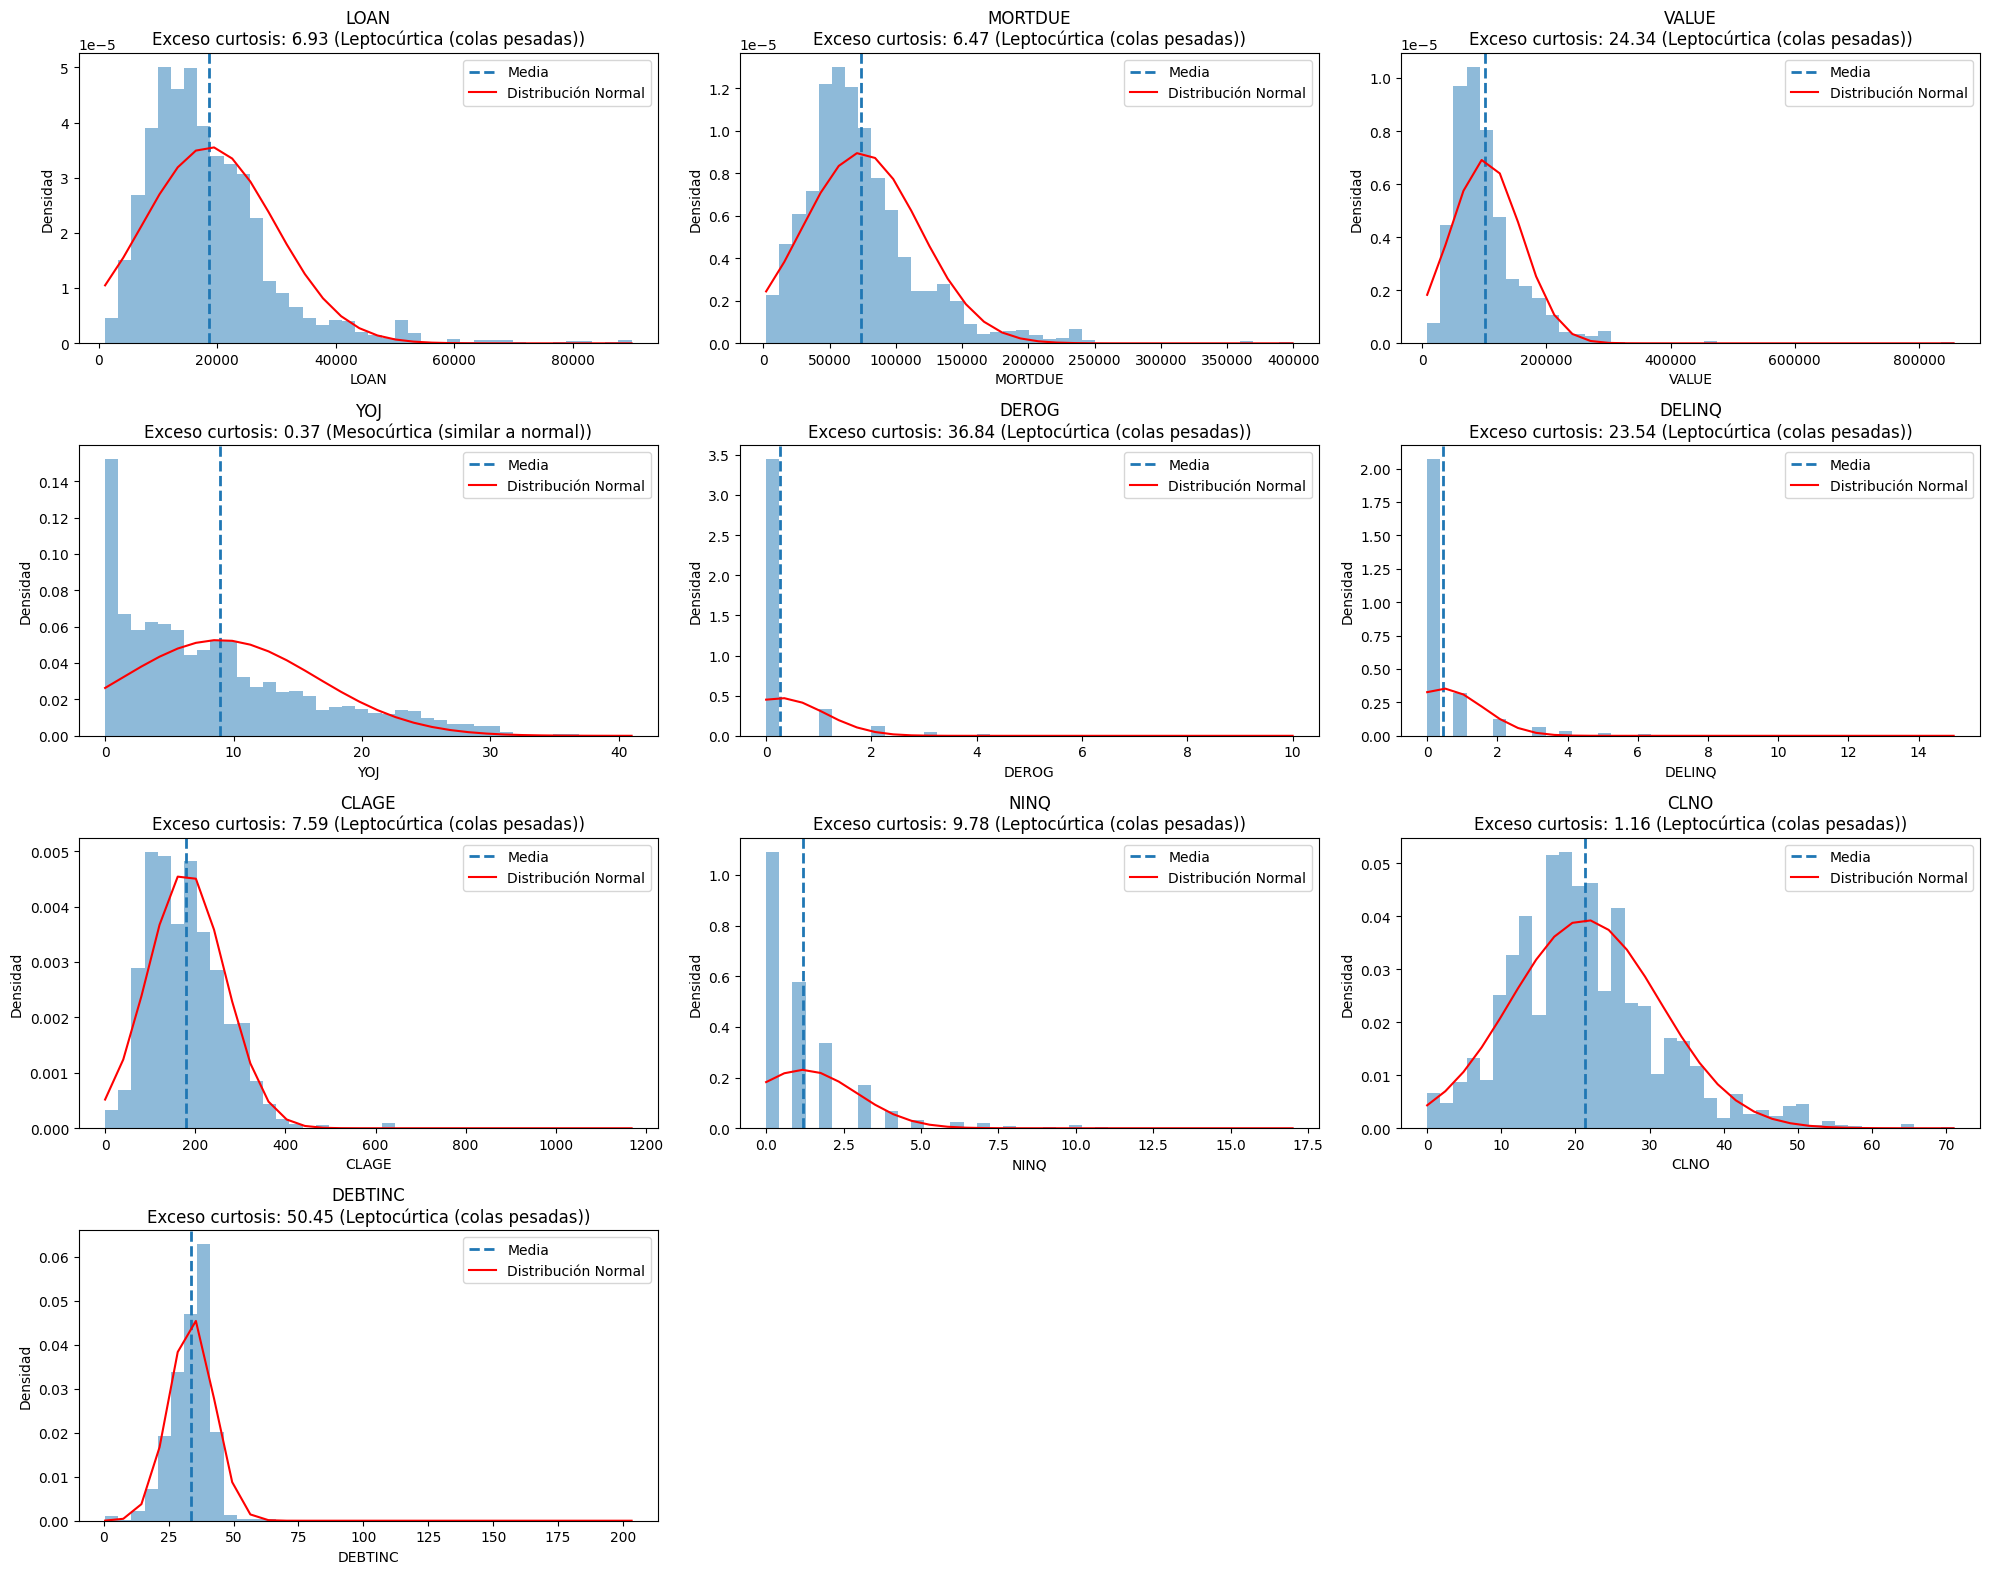

In [55]:
num_cols = ["DEROG", "DELINQ","NINQ","DEBTINC","YOJ", "LOAN", "MORTDUE", "VALUE",   "CLAGE",  "CLNO"]
num_vars = hmeq.select_dtypes(include="number").drop(columns="BAD") # Excluimos la variable objetivo

def kurtosis_type(excess_kurt): # Clasificacion del tipo de curtosis (opcional)
    """
    Clasifica la distribución según la curtosis en exceso
    """
    if excess_kurt > 0.5:
        return "Leptocúrtica (colas pesadas)"
    elif excess_kurt < -0.5:
        return "Platicúrtica (aplanada)"
    else:
        return "Mesocúrtica (similar a normal)"

# Visualización de histogramas con ajuste de distribución normal y clasificación de curtosis
fig, axes = plt.subplots(4,3, figsize=(20, 16))
axes = axes.flatten()
for i, col in enumerate(num_vars.columns):
    # Eliminamos valores nulos
    num_vars_sin_nulos = num_vars[col].dropna()
    mean = num_vars_sin_nulos.mean()
    std = num_vars_sin_nulos.std()
    # Calculamos curtosis en exceso
    excess_kurt = kurtosis(num_vars_sin_nulos, fisher=True)
    dist_type = kurtosis_type(excess_kurt)
    # Clasificamos la distribución
    ax = axes[i]

# Histograma normalizado
    ax.hist(num_vars_sin_nulos, bins=40, density=True, alpha=0.5)
    ax.axvline(mean, linestyle="--", linewidth=2, label="Media")
    x = np.linspace(num_vars_sin_nulos.min(), num_vars_sin_nulos.max(), 30)
    y = norm.pdf(x, mean, std)
    ax.plot(x, y, color="red", label="Distribución Normal")
    ax.set_title(
        f"{col}\n"
        f"Exceso curtosis: {excess_kurt:.2f} ({dist_type})"
    )
    ax.set_xlabel(col)
    ax.set_ylabel("Densidad")
    ax.legend()

for j in range(i + 1, len(axes)): ## Ocultamos axes sobrantes (look and feel)
   axes[j].set_visible(False)

plt.tight_layout()
plt.show()

<small>

La inspección visual de los histogramas de **HMEQ** permite identificar varias características habituales en datos de riesgo de crédito. En primer lugar, se observa una **asimetría positiva** en la mayoría de las variables financieras y de comportamiento, como *LOAN*, *MORTDUE*, *VALUE*, *DEBTINC*, *DELINQ* y *NINQ*, con una elevada concentración de observaciones en valores bajos y colas derechas largas.

Asimismo, se aprecia la **presencia de valores extremos (outliers)**, especialmente en los importes monetarios y ratios financieros, lo cual refleja la heterogeneidad del perfil de los prestatarios. Las variables de comportamiento crediticio, como *DEROG*, *DELINQ* y *NINQ*, presentan una **alta frecuencia de valores cero**, indicando que la mayoría de los clientes no registra incidencias negativas, mientras que una minoría concentra un mayor nivel de riesgo.

Por otro lado, variables relacionadas con la antigüedad del historial crediticio o laboral, como *CLAGE* y *YOJ*, muestran distribuciones más dispersas. En conjunto, la heterogeneidad en las escalas y formas de las distribuciones sugiere la conveniencia de aplicar técnicas de normalización o transformaciones en fases posteriores del análisis, especialmente para modelos sensibles a la escala de las variables.

Este análisis exploratorio confirma que las distribuciones observadas son coherentes con un problema real de **scoring crediticio** y permite anticipar decisiones clave en las etapas de preprocesado y modelización.

La curtosis permite identificar variables con colas pesadas, donde eventos poco frecuentes pueden tener un impacto desproporcionado en el riesgo de crédito.
En este caso, confirma la presencia generalizada de colas pesadas y desviaciones significativas respecto a la normalidad, especialmente en variables financieras y de comportamiento crediticio. Este resultado justifica la aplicación de transformaciones y técnicas robustas en la fase de modelización, evitando supuestos de normalidad que no se sostienen empíricamente en carteras crediticias reales.

</small>

#### 3.4 Análisis de calidad del dato

In [56]:
# Análisis de valores nulos
print("Porcentaje de nulos:") 
porcentaje_nulos = ((hmeq.isna().sum().sort_values(ascending=False) / len(hmeq)) * 100).round(2)
porcentaje_nulos_filtrado = porcentaje_nulos[porcentaje_nulos > 0]
print(porcentaje_nulos_filtrado)

Porcentaje de nulos:
DEBTINC    21.26
DEROG      11.88
DELINQ      9.73
MORTDUE     8.69
YOJ         8.64
NINQ        8.56
CLAGE       5.17
JOB         4.68
REASON      4.23
CLNO        3.72
VALUE       1.88
dtype: float64


<Axes: >

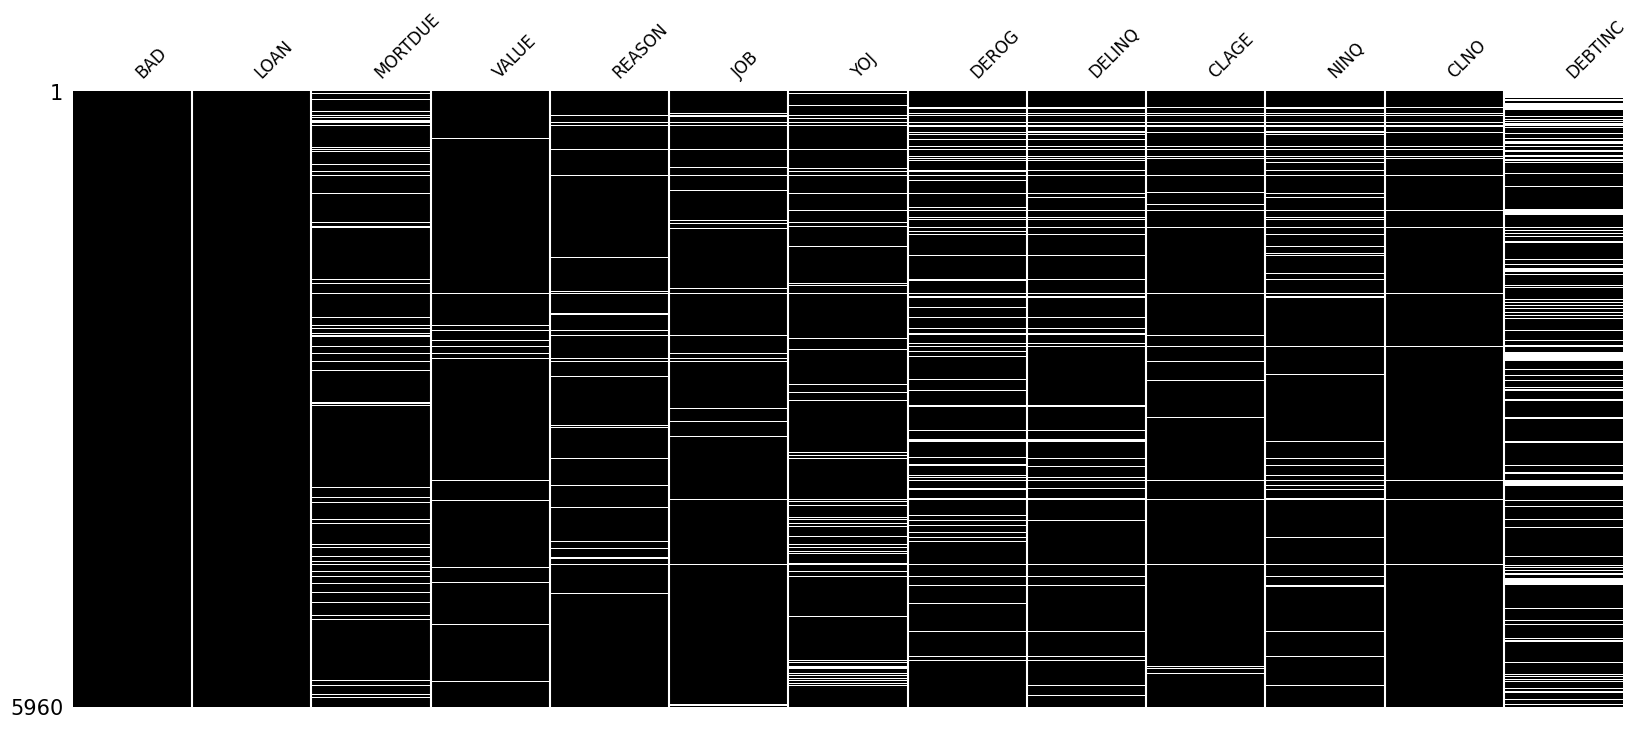

In [57]:
# Crear un mapa de valores faltantes
msno.matrix(hmeq, figsize=(20, 8), color=(0, 0, 0), fontsize=12, sparkline=False)

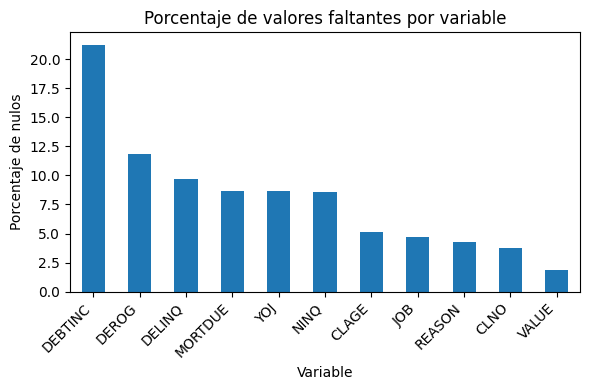

In [58]:
# Gráfico de barras del % de nulos
plt.figure(figsize=(6, 4))
porcentaje_nulos_filtrado.plot(kind="bar")
plt.title("Porcentaje de valores faltantes por variable")
plt.xlabel("Variable")
plt.ylabel("Porcentaje de nulos")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

<small>

- Los datos presentan missing values en la mayoría de variables a excepción de LOAN y BAD. Especial atención DEBTINC o ratio deuda-ingresos donde hay 21.26% de valores faltantes. Esta situación es coherente con la realidad bancaria, donde la información de ingresos puede no estar disponible, ser incompleta o no verificable en determinados clientes.

- Variables de comportamiento crediticio como DEROG (derogatory reports, 12 %) y DELINQ (delinquencies, ~10 %) también presentan missing values, lo que resulta especialmente relevante desde una perspectiva de riesgo, al tratarse de indicadores clave para la identificación de historiales de mora o incidencias graves.

- La presencia de nulos en este tipo de variables sugiere que **los valores faltantes no pueden asumirse como completamente aleatorios**, por lo que su tratamiento deberá evaluarse cuidadosamente en la fase de preprocesamiento. 

- En esta sección se analizan los posibles mecanismos de generación de valores faltantes (MCAR, MAR y MNAR), cuya correcta identificación resulta crítica para evitar sesgos en la estimación de la Probabilidad de Incumplimiento (PD).
    - **MCAR** considera que la razon de tener missing es complemente aleatoria. No resulta consistente porque, como hemos mencionado, puede haber dificulta para verificar ingresos o falta de historial crediticio del cliente. Este mecanismo podría afectar puntualmente a variables como CLAGE, CLNO o VALUE, especialmente cuando la información procede de sistemas históricos heterogéneos o de fuentes externas. En este caso, la ausencia de información no estaría correlacionada ni con el incumplimiento (BAD) ni con otras variables explicativas del dataset.
    - **MAR**: la ausencia de información puede estar condicionada por otras características observables del cliente incluidas en el dataset. El missing en DEBTINC puede relacionarse con variables como el empleo (impide determinar el ingreso) o MORTDUE el cual impide determinar la deuda. A continuación hay un celda que puede justificar este mecanismos. 
    - **MNAR**: En variables de comportamiento crediticio como DEROG, DELINQ o NINQ, la ausencia de información podría estar directamente relacionada con el nivel de riesgo crediticio del cliente. Por ejemplo, clientes con historiales crediticios más deteriorados o incompletos pueden presentar mayor probabilidad de no disponer de información consolidada sobre incidencias, líneas en mora o consultas recientes. En este caso, el missing puede contener información implícita de riesgo

</small>

In [ ]:
# MCAR , MNAR y MNAR
''' En clientes que entran en default, el Debt-to-Income Ratio no está disponible en 2/3 de los casos. 
Es MNAR y por lo tanto, un indicativo de riesgo que habrá que considerar creando un flag de missing.

Value es otro indicar a considerar de riesgo ya que la mayoría de sus missing ocurren cuando hay default.
Ocurre lo contrario y mucho menos extremo con variables DEROG, DELING Y NINQ.'''
hmeq.groupby("BAD")[num_cols].apply(lambda x: x.isna().mean() * 100).round(2).transpose()

BAD,0,1
DEROG,13.02,7.32
DELINQ,10.65,6.06
NINQ,9.12,6.31
DEBTINC,10.08,66.11
YOJ,9.43,5.47
LOAN,0.00,0.00
MORTDUE,8.64,8.92
VALUE,0.15,8.83
CLAGE,4.82,6.56
CLNO,3.54,4.46


<small>

- El análisis de la tasa de incumplimiento muestra que los clientes con ausencia simultánea de información en DEBTINC y MORTDUE presentan una probabilidad de incumplimiento sustancialmente superior, lo que indica que los valores faltantes contienen información implícita de riesgo y son consistentes con un mecanismo MNAR.
- Su tratamiento será tenido en cuenta en el preprocesamiento evitando imputaciones aleatorias sobre todo en variables que estan asociacianas a un mayor nivel de incumplimiento. **Plantear si hacer lo mismo con el resto de variables missing**  
- En consecuencia, en el pipeline de preprocesamiento se combinará imputación estadística con la creación de indicadores binarios de ausencia de información para aquellas variables en las que el missing haya mostrado asociación con la probabilidad de incumplimiento.

</small>

In [45]:
# Valores extremos
# Cálculo del rango intercuartílico
outliers_iqr = {}

for col in num_vars: # num_vars calculada anteriormente
    q1 = hmeq[col].quantile(0.25)
    q3 = hmeq[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr # Valor de referencia 1.5 veces el IQR
    upper = q3 + 1.5 * iqr
    
    outliers_iqr[col] = ((hmeq[col] < lower) | (hmeq[col] > upper)).mean() * 100

df_outliers = pd.DataFrame.from_dict(
    outliers_iqr, orient="index", columns=["pct_outliers_IQR"]
).round(2)

df_outliers.sort_values("pct_outliers_IQR", ascending=False)


,pct_outliers_IQR
DELINQ,20.15
DEROG,12.16
VALUE,5.37
LOAN,4.30
MORTDUE,3.93
CLNO,3.67
NINQ,2.97
DEBTINC,1.58
YOJ,1.53
CLAGE,0.79


In [ ]:
# % de BAD en valores extremos percentil 75 - 100 
resultados_outliers = []

for col in num_vars:
    q1 = hmeq[col].quantile(0.25)
    q3 = hmeq[col].quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outliers = hmeq[hmeq[col] > upper]
    no_outliers = hmeq[hmeq[col] <= upper]
    if len(outliers) > 0:
        tasa_bad_outliers = outliers['BAD'].mean() * 100
        tasa_bad_normal = no_outliers['BAD'].mean() * 100
        n_outliers = len(outliers)

        resultados_outliers.append({
            'Variable': col,
            '% outliers': round(n_outliers / len(hmeq) * 100, 2),
            'Tasa BAD outliers (%)': round(tasa_bad_outliers, 2),
            'Tasa BAD normal (%)': round(tasa_bad_normal, 2),
            'Diferencia (pp)': round(tasa_bad_outliers - tasa_bad_normal, 2)
        })

df_bad_outliers = pd.DataFrame(resultados_outliers)
df_bad_outliers = df_bad_outliers.sort_values('Diferencia (pp)', ascending=False)
df_bad_outliers

,Variable,% outliers,Tasa BAD outliers (%),Tasa BAD normal (%),Diferencia (pp)
9,DEBTINC,0.59,100.00,7.90,92.10
4,DEROG,12.16,48.00,16.66,31.34
5,DELINQ,20.15,44.46,13.95,30.51
7,NINQ,2.97,44.63,19.63,25.00
8,CLNO,3.67,25.57,19.57,6.00
1,MORTDUE,3.93,23.93,19.72,4.21
0,LOAN,4.30,22.27,19.85,2.42
2,VALUE,5.37,20.31,18.43,1.88
3,YOJ,1.53,15.38,20.73,-5.35
6,CLAGE,0.79,6.38,19.77,-13.39


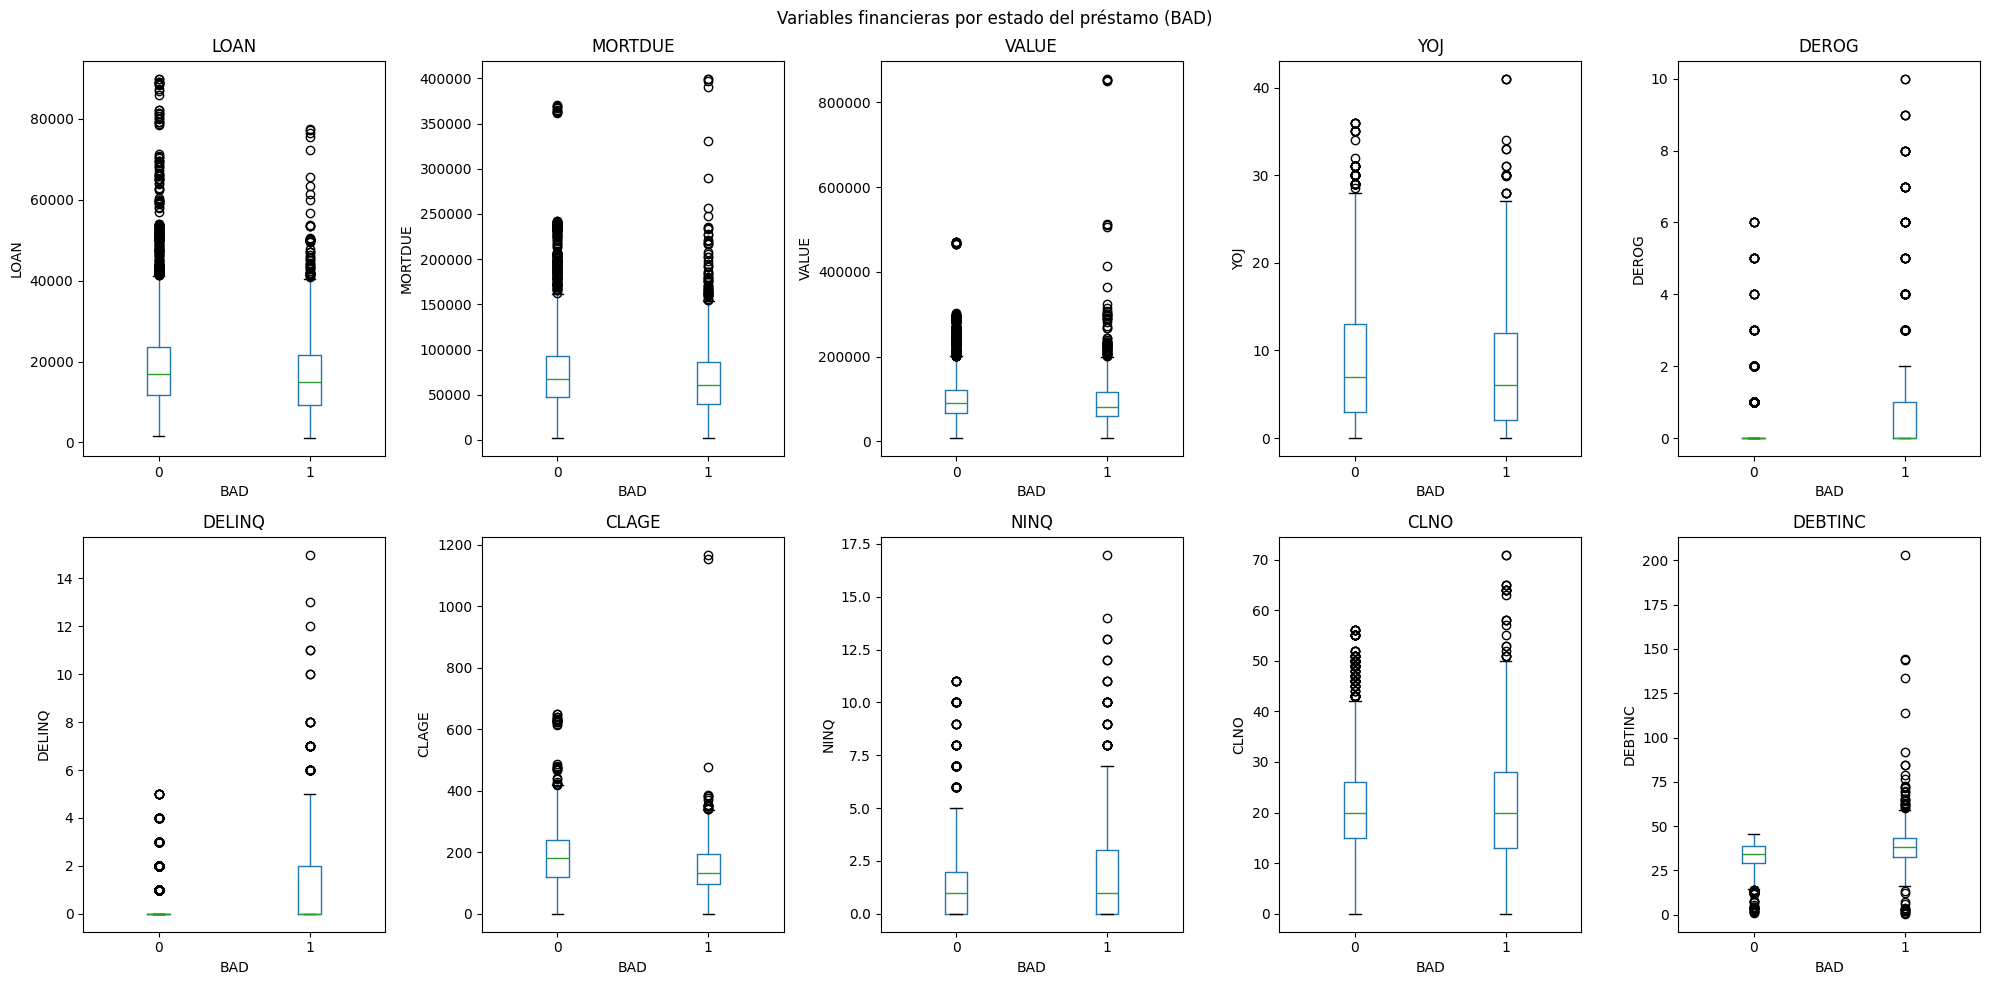

In [ ]:
# Visualización 
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for ax, var in zip(axes, num_vars):
    hmeq.boxplot(column=var, by="BAD", ax=ax, grid=False)
    ax.set_title(var)
    ax.set_xlabel("BAD")
    ax.set_ylabel(var)

fig.suptitle("Variables financieras por estado del préstamo (BAD)")
plt.tight_layout()
plt.show()

<small>

- La segmentación de los valores extremos por la variable objetivo (BAD) refuerza la hipótesis de que el riesgo se concentra en estos registros. En particular, las variables de comportamiento crediticio como DELINQ, DEROG y NINQ presentan un mayor número de outliers, siendo además estos más extremos en los clientes en incumplimiento (BAD = 1) que en aquellos al corriente de pago (BAD = 0).  
- Este comportamiento refuerza la hipótesis de que los outliers contienen información relevante de riesgo y no responden a errores de calidad del dato, sino a situaciones crediticias adversas.  
- En consecuencia, en la fase de preprocesamiento, no se eliminarán los valores extremos, con el objetivo de preservar la señal de riesgo y no deteriorar la capacidad predictiva del modelo.  

</small>

#### 3.5 Análisis multivariante.

Aprovechando la visualización boxplot, podemos apreciar que las variable de comportamiento crediticio muestran una clara separación entre préstamos al corriente y en incumplimiento. Los clientes con valores más elevados en estas variables presentan una mayor probabilidad de default, confirmando su papel como drivers fundamentales del riesgo de crédito. 
Del mismo modo en sentido contrario, variables de estabilidad YOJ e historial crediticio presenta valores mas bajos en aquellos registros en incumplimineto.  
Por lo tanto una conclusión a tener en cuenta es:  
    - Variables asociadas a un menor riesgo: CLAGE y YOJ  
    - Variables asociadas a un mayor riesgo: DEBTINC, DELINQ, DEROG y NINQ

In [ ]:
# Matriz de correlaciones
spearman_corr = num_vars.corr(method='spearman')
spearman_corr

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
LOAN,1.000000,0.198513,0.345843,0.092240,0.007437,-0.061409,0.122700,0.043359,0.143107,0.120495
MORTDUE,0.198513,1.000000,0.861173,-0.058010,-0.039245,-0.027094,0.131229,0.055517,0.346071,0.180289
VALUE,0.345843,0.861173,1.000000,0.031962,-0.054440,-0.036480,0.193142,0.012652,0.364094,0.166389
YOJ,0.092240,-0.058010,0.031962,1.000000,-0.066582,0.028961,0.172755,-0.061186,0.045379,-0.065466
DEROG,0.007437,-0.039245,-0.054440,-0.066582,1.000000,0.240796,-0.085370,0.171612,0.041252,0.013896
DELINQ,-0.061409,-0.027094,-0.036480,0.028961,0.240796,1.000000,-0.000471,0.077324,0.147825,0.045863
CLAGE,0.122700,0.131229,0.193142,0.172755,-0.085370,-0.000471,1.000000,-0.098424,0.241881,0.008436
NINQ,0.043359,0.055517,0.012652,-0.061186,0.171612,0.077324,-0.098424,1.000000,0.149025,0.205032
CLNO,0.143107,0.346071,0.364094,0.045379,0.041252,0.147825,0.241881,0.149025,1.000000,0.191757
DEBTINC,0.120495,0.180289,0.166389,-0.065466,0.013896,0.045863,0.008436,0.205032,0.191757,1.000000


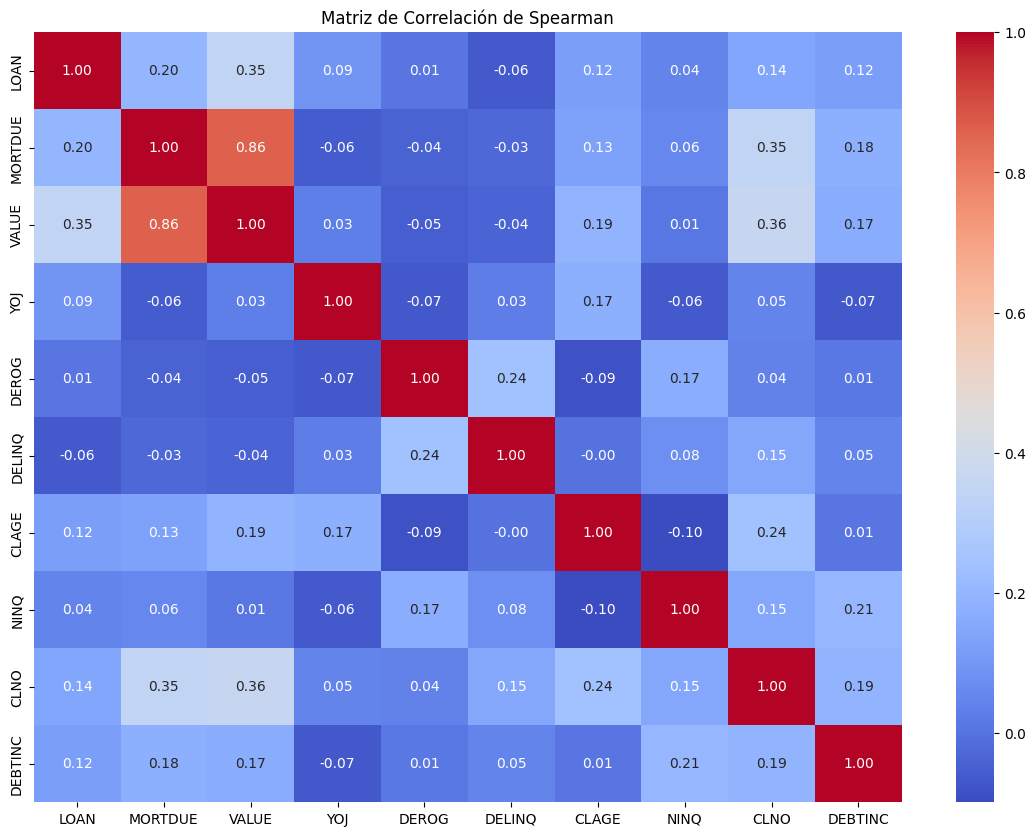

In [ ]:
# Visualización de la matriz de correlaciones Spearman
plt.figure(figsize = (14,10)) 
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlación de Spearman")
plt.show()

- Se ha utilizado la correlación de Spearman para medir la correlación entre variables e identificar posibles problemas de colinealidad entre las features. Esta correlación mide la asociación monótona y es más robusto en distribuciones asimétricas y outliers (algo que ocurre en nuestros datos de crédito).
- La correlación es elevada en dos variables, el saldo hipotecario pendiente (MORTDUE) y el valor del inmueble (VALUE) con un coeficiente ρ ≈ 0.79. Esta correlación es coherente desde el punto de vista económico pero puede generar problemas de colinealidad y por lo tanto la capacidad explicativa del modelo se puede ver comprometida. 
- En el resto de variables no se observa correlación elevada
- Desde el punto de vista del preprocesamiento, estos resultados indican la conveniencia de no incluir simultáneamente MORTDUE y VALUE en el modelo. Como alternativa, se plantea la transformación de ambas variables en un ratio financiero, como el **Loan-to-Value (LTV)**, práctica habitual en la modelización del riesgo de crédito. El resto de variables puede mantenerse sin ajustes adicionales por colinealidad.

In [ ]:
cat_vars = hmeq.select_dtypes(include="object")

In [ ]:
cat_vars.describe()

,REASON,JOB
count,5708,5681
unique,2,6
top,DebtCon,Other
freq,3928,2388


In [ ]:
# Análisis de variables categóricas respecto a la variable objetivo
cat_vars = hmeq.select_dtypes(include="object").columns
for var in ["REASON", "JOB"]:
    display(
        hmeq
        .groupby(var)["BAD"]
        .agg(
            n_obs="count",
            default_rate="mean"
        )
        .assign(default_rate=lambda x: (x["default_rate"] * 100).round(2))
        .sort_values("default_rate", ascending=False)
    )


,n_obs,default_rate
REASON,,
HomeImp,1780,22.25
DebtCon,3928,18.97


,n_obs,default_rate
JOB,,
Sales,109,34.86
Self,193,30.05
Mgr,767,23.34
Other,2388,23.20
ProfExe,1276,16.61
Office,948,13.19


In [66]:
resultados_cat = {}

for var in ["REASON", "JOB"]:
    resultados_cat[var] = (
        hmeq
        .groupby(var)["BAD"]
        .agg(n_obs="count", default_rate="mean")
        .assign(default_rate=lambda x: (x["default_rate"] * 100).round(2))
        .sort_values("default_rate", ascending=False)
        .reset_index()
        .rename(columns={
            var: "Categoría",
            "n_obs": "N observaciones",
            "default_rate": "Tasa de impago (%)"
        })
    )

resultados_cat

{'REASON':   Categoría  N observaciones  Tasa de impago (%)
 0   HomeImp             1780               22.25
 1   DebtCon             3928               18.97,
 'JOB':   Categoría  N observaciones  Tasa de impago (%)
 0     Sales              109               34.86
 1      Self              193               30.05
 2       Mgr              767               23.34
 3     Other             2388               23.20
 4   ProfExe             1276               16.61
 5    Office              948               13.19}

- En relación a la finalidad del prestamo, la diferencia de default es moderada, por lo que  la consideraremos para el modelo aunque con capacidad limitada. 
- Es relevante el tipo de empleo ya que ventas y autonomos tienen asignado una mayor probabilidad de default. 
- En el preprocesamiento, se usará One Hot enconding ya que no impone jerarquia y no son muchas categorias (2 y 6, respectivamente)

#### 3.6 Sintensis del EDA

El análisis exploratorio de datos ha permitido caracterizar en profundidad la estructura del dataset HMEQ y extraer conclusiones clave para la fase de preprocesamiento y modelización.

En primer lugar, la variable objetivo BAD presenta un desbalanceo significativo, consistente con carteras reales de crédito retail. Este hecho descarta el uso de métricas como el accuracy y justifica la evaluación de los modelos mediante métricas basadas en probabilidad y discriminación, como AUC/Gini, Brier Score y curvas de calibración.

El análisis univariante y visual ha evidenciado asimetría positiva, colas derechas largas y curtosis elevada en la mayoría de las variables financieras y de comportamiento crediticio. Asimismo, la identificación de valores extremos ha mostrado que estos se concentran principalmente en clientes en incumplimiento, por lo que los outliers se consideran informativos al considerarse parte de la señal de riesgo.

Desde el punto de vista de calidad del dato, se ha demostrado que los valores faltantes, especialmente en variables como **DEBTINC, MORTDUE, DEROG, DELINQ y NINQ, no pueden asumirse como completamente aleatorios**. El análisis empírico confirma mecanismos MAR y MNAR, mostrando que la ausencia de información contiene señal directa de riesgo. En consecuencia, se ha decidido **complementar la imputación estadística con indicadores explícitos de missing (MISS_*)**, preservando esta información implícita.

En consecuencia, el tratamiento adoptado será el siguiente:

   - Para DEBTINC y VALUE, se incorporarán indicadores binarios explícitos de ausencia (MISS_*), preservando la señal implícita en el patrón de missing.
   - La imputación de valores numéricos se realizará mediante mediana, en lugar de media, dada la fuerte asimetría y curtosis observadas en las distribuciones. La mediana constituye una medida- robusta frente a valores extremos y garantiza mayor estabilidad del modelo.
   - La mediana será calculada exclusivamente sobre el conjunto de entrenamiento, evitando cualquier riesgo de data leakage.

El análisis bivariante frente a BAD ha permitido identificar claramente los drivers de default (DELINQ, DEROG, NINQ, DEBTINC) y los detractores de riesgo (CLAGE, YOJ), mientras que las variables categóricas (REASON, JOB) muestran capacidad discriminante moderada y se incorporarán mediante One-Hot Enconding.

Finalmente, el análisis de correlaciones (Spearman) identifica una dependencia elevada entre MORTDUE y VALUE (ρ≈0,86), coherente desde el punto de vista económico al relacionarse ambos con el colateral y el saldo hipotecario. Esta relación puede generar redundancia informativa y multicolinealidad en modelos lineales. Como alternativa, se plantea la transformación de ambas variables en un ratio financiero, **Loan-to-Value (LTV)**, calculado tras la imputación de VALUE para evitar generación de nuevos valores nulos o infinitos.  
El dataset es Home Equity Loan por lo que LTV incluye el mortgage actual y el prestamos solicitado

$LTV = \frac{LOAN + MORTDUE}{VALUE}$

Sobre la base de estos resultados, se ha definido un pipeline de preprocesamiento estructurado, que incluye:

|  Step |  Descripción | 
|----------|:---------|
| Missing Values | Creación de indicadores de missing en variables seleccionadas |
| Missing Values 2 | Imputación robusta mediante mediana. |
| Transformación Nuevas Variables | Construcción de variables financieras derivadas (LTV). |
| Normalización variables numéricas | Escalado de variables numéricas. |
| Codificación variables categóricas | Codificación One-Hot de variables categóricas. |

Como modelo principal se empleará una Regresión Logística con transformación Weight of Evidence (WoE), alineada con el estándar de la industria para la construcción de scorecards de riesgo. Este enfoque permite garantizar interpretabilidad, monotonicidad económica y estabilidad temporal, facilitando la construcción de un modelo explicable y coherente con la práctica bancaria en estimación de Probabilidad de Incumplimiento.

De forma complementaria, se evaluará un modelo más flexible como benchmark, concretamente XGBoost, con el objetivo de capturar posibles interacciones no lineales y contrastar la capacidad predictiva frente al modelo base. Este análisis comparativo permitirá evaluar el trade-off entre interpretabilidad y potencia predictiva, manteniendo la regresión logística como modelo principal por su mayor alineación regulatoria.

La evaluación de los modelos se realizará utilizando métricas alineadas con el objetivo de estimar probabilidades de incumplimiento fiables y bien calibradas. En particular, se emplearán:

   - AUC / Gini para medir la capacidad de discriminación.  
   - Brier Score como métrica de calidad probabilística.  
   - Curvas de calibración para evaluar la adecuación de las probabilidades estimadas.  
   - KS statistic como métrica complementaria ampliamente utilizada en riesgo de crédito.  

En conjunto, el EDA realizado proporciona una base sólida y coherente para la fase de modelización, asegurando que las decisiones de preprocesamiento y selección de modelos están plenamente justificadas tanto desde una perspectiva académica como desde la práctica profesional en gestión del riesgo de crédito.